<a href="https://colab.research.google.com/github/EgorMatveev26/MO_Attack/blob/main/lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 2. Построение baseline-модели: от выбора парадигмы к метрикам качества

**Курс:** Машинное обучение. Безопасность ИИ-систем

**Формат:** индивидуально

**Среда:** Python, scikit-learn, PyTorch

**По материалам Лекции 2.1 и Лекции 2.2**

## Цель работы
Научиться выбирать тип задачи, датасет, baseline-модель и метрики качества, а также сопоставлять структуру данных с соответствующей архитектурой или классическим алгоритмом.

## Результаты обучения
После выполнения работы вы должны уметь:
- различать парадигмы обучения (supervised / unsupervised / reinforcement learning);
- выбирать модель под тип данных и задачу;
- строить baseline для классификации или регрессии;
- выбирать и интерпретировать метрики качества (accuracy, precision, recall, F1, MSE, RMSE, R²);
- сравнивать несколько моделей и делать обоснованный вывод о лучшем baseline.

## Как пользоваться этим ноутбуком
- Ячейки с `# TODO` необходимо заполнить самостоятельно.
- Ячейки с текстом **"Вопрос для отчёта"** требуют письменного ответа в markdown-ячейке ниже.
- Перед сдачей: Kernel → Restart & Run All, ноутбук должен выполняться от начала до конца без ошибок.


## 0. Подготовка окружения

In [ ]:
# TODO: импортируйте необходимые библиотеки
# Подсказка: numpy, pandas, matplotlib, sklearn.*

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# TODO: зафиксируйте random_state для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Постановка задачи

**Задание:** выберите один датасет из списка (или согласуйте свой с преподавателем) и определите тип задачи.

Варианты:
- **fetch_20newsgroups** — многоклассовая классификация;
- **diabetes** — регрессия.
- **MNIST** — классификация изображений, простая MLP-модель.

**Вопрос для отчёта:** к какой парадигме обучения относится ваша задача (supervised / unsupervised / reinforcement learning) и почему? Какой тип задачи вы решаете — классификация или регрессия?


_Ваш ответ:_

Задача относится к supervised learning (обучение с учителем), так как для каждого пациента известна целевая переменная target, и модель обучается на размеченных парах (признаки-ответ). Тип задачи — регрессия, поскольку целевая переменная непрерывная (числовое значение прогрессирования диабета), а не дискретная метка класса.

## 2. Загрузка и разведочный анализ данных (EDA)

In [ ]:
# TODO: загрузите выбранный датасет
# Пример для sklearn built-in датасетов:
# from sklearn.datasets import load_iris
# data = load_iris(as_frame=True)
# df = data.frame

data = load_diabetes(as_frame=True)
df = data.frame
df.head() if df is not None else None


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [ ]:
# TODO: проведите разведочный анализ данных
# - размер выборки (df.shape)
# - типы признаков и целевая переменная (df.dtypes)
# - наличие пропусков (df.isna().sum())
# - баланс классов для классификации (df[target].value_counts())
# - базовые статистики (df.describe())

# размер выборки
print(f"Размер выборки: {df.shape}")

# типы данных
print(f"\nТипы данных:\n{df.dtypes}")

# пропуски
print(f"\nПропуски:\n{df.isna().sum()}")

# целевая переменная
target = 'target'
print(f"\nЦелевая переменная: '{target}'")
print(f"Тип: {df[target].dtype}, уникальных значений: {df[target].nunique()}")

# баланс классов
print(f"\nРаспределение target:")
print(df[target].value_counts())

# базовые статистики
print(f"\nБазовые статистики:\n{df.describe()}")


Размер выборки: (442, 11)

Типы данных:
age       float64
sex       float64
bmi       float64
bp        float64
s1        float64
s2        float64
s3        float64
s4        float64
s5        float64
s6        float64
target    float64
dtype: object

Пропуски:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

Целевая переменная: 'target'
Тип: float64, уникальных значений: 214

Распределение target:
target
200.0    6
72.0     6
178.0    5
71.0     5
90.0     5
        ..
146.0    1
212.0    1
120.0    1
183.0    1
57.0     1
Name: count, Length: 214, dtype: int64

Базовые статистики:
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02

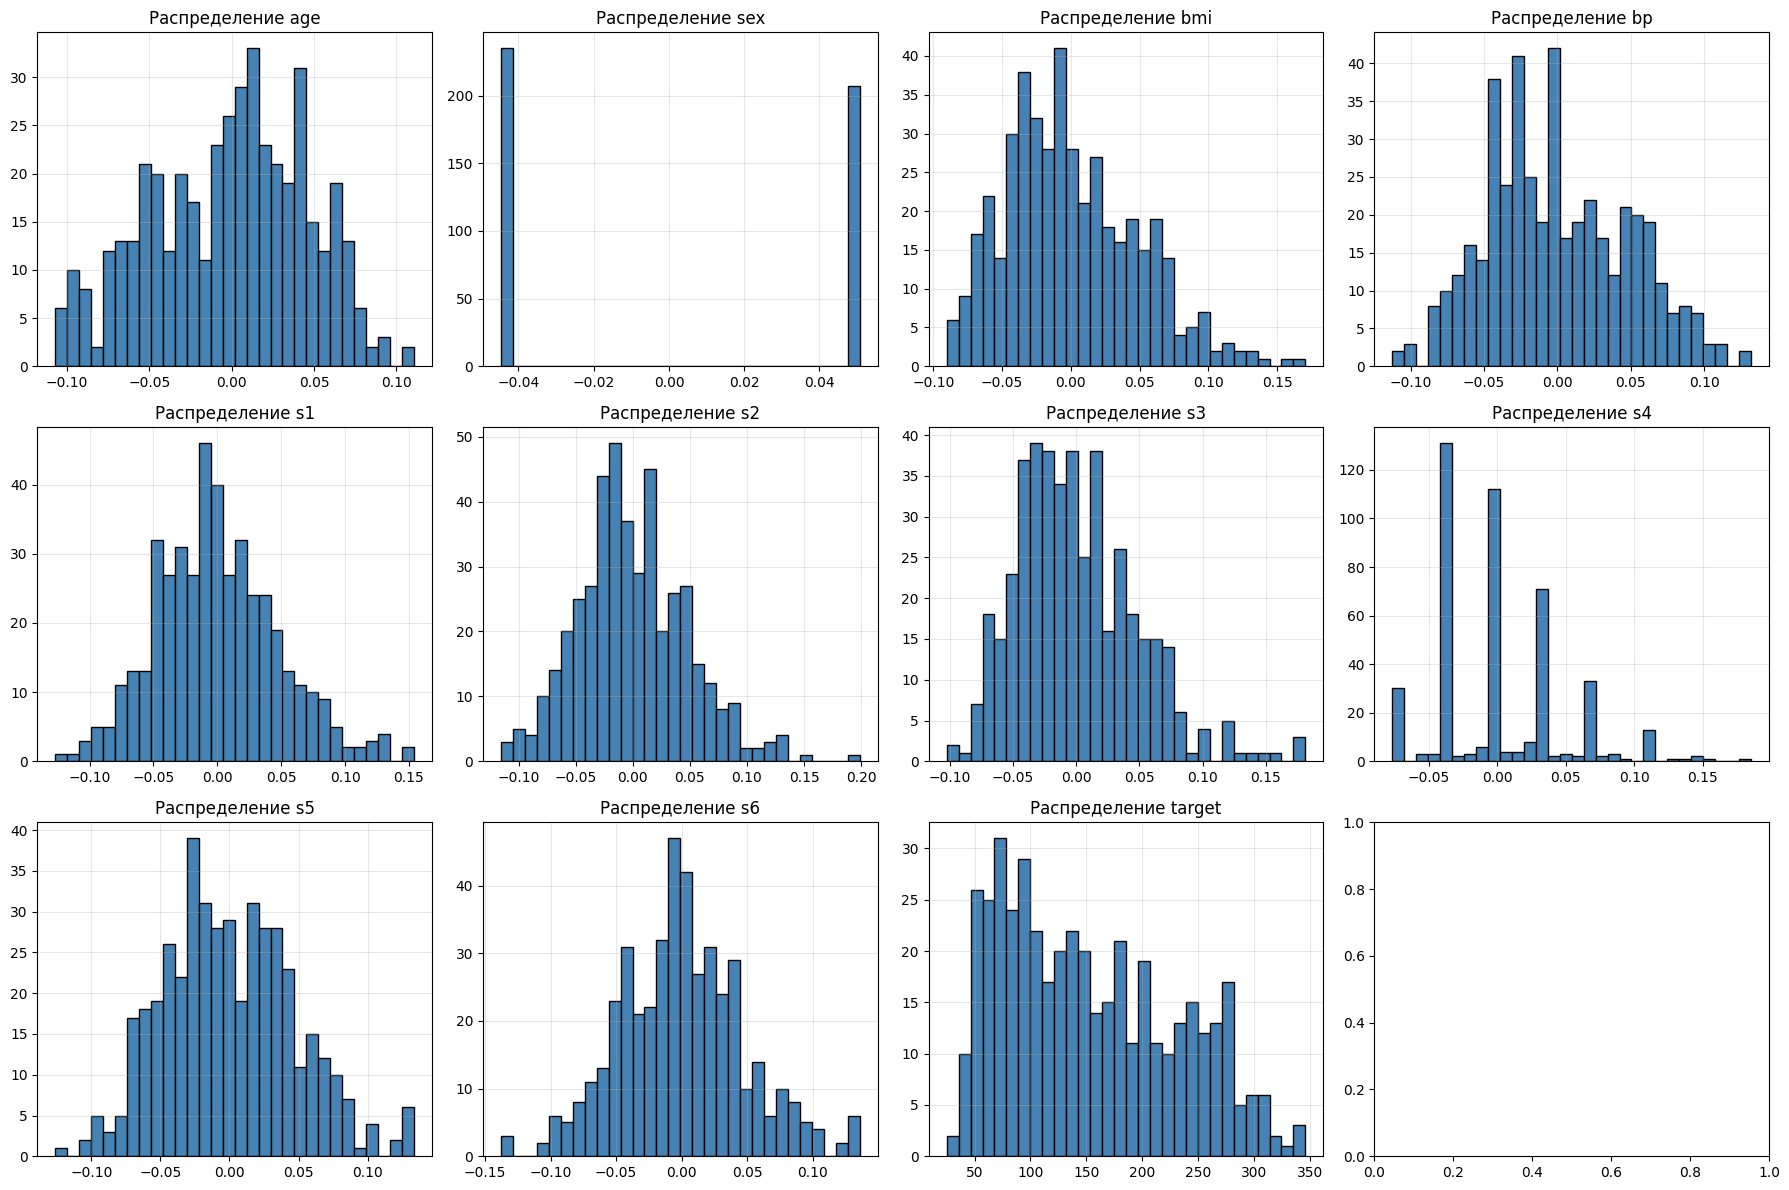

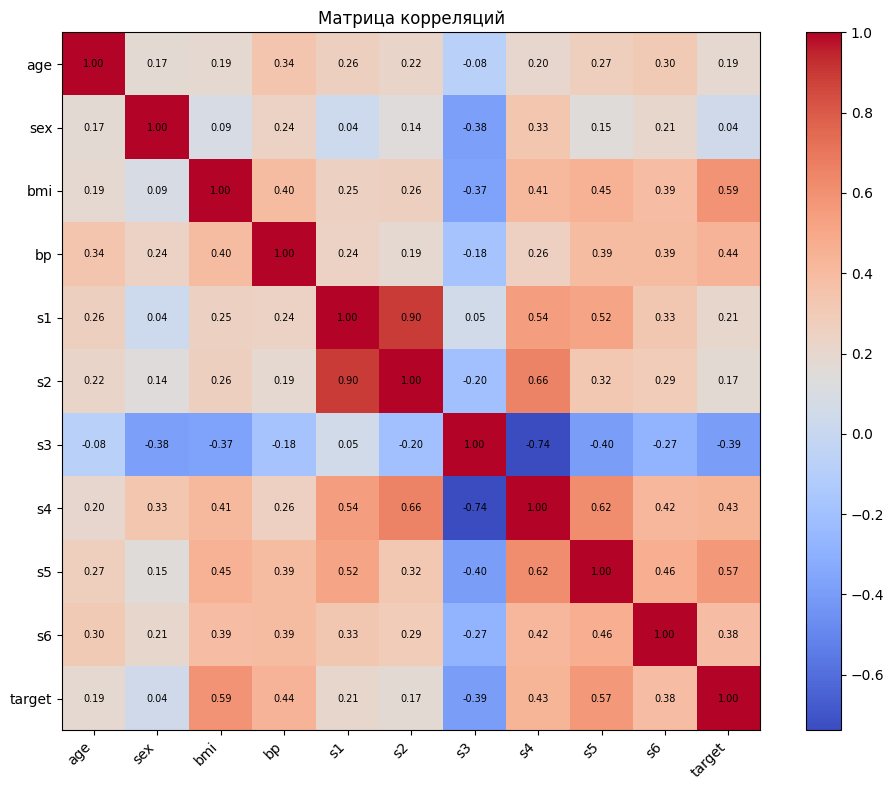


Корреляция признаков с target:
bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
s3    -0.394789
Name: target, dtype: float64


In [ ]:
# визуализация распределений
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Распределение {col}')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# матрица корреляций
plt.figure(figsize=(10, 8))
corr = df.corr()
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)
plt.title('Матрица корреляций')
plt.tight_layout()
plt.show()

print("\nКорреляция признаков с target:")
print(corr[target].drop(target).sort_values(ascending=False))

**Вопрос для отчёта:** есть ли в данных пропуски, дисбаланс классов или сильно различающиеся масштабы признаков? Как это повлияет на выбор моделей и предобработки?

_Ваш ответ:_

Пропусков нет. Дисбаланс классов неприменим, т.к. задача регрессионная. Признаки уже стандартизированы (т.к. среднее значение каждого признака mean почти 0 и стандартное отклонение каждого признака std маленькое и одинаковое), поэтому дополнительное масштабирование не обязательно. Ожидается, что линейные модели покажут хороший результат благодаря линейным зависимостям в данных, а k-NN и деревья могут уступать из-за малого размера выборки.

## 3. Предобработка данных

In [ ]:
# TODO: разделите данные на train/test (train_test_split)
# TODO: при необходимости выполните масштабирование признаков (StandardScaler / MinMaxScaler)
# TODO: при необходимости выполните кодирование категориальных признаков (OneHotEncoder / get_dummies)

from sklearn.model_selection import train_test_split

# разделение на признаки и целевую переменную
X = df.drop(columns=[target])
y = df[target]

# train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (353, 10), Test: (89, 10)


## 4. Обучение моделей

**Задание:** обучите не менее **трёх** моделей из списка (минимум одну классическую и минимум одну альтернативную):
- логистическая / линейная регрессия;
- дерево решений;
- k-NN;
- простой MLP.


In [ ]:
# Модель 1(линейная регрессия)
# TODO: импортируйте и обучите первую модель
model_1 = LinearRegression()
model_1.fit(X_train, y_train)


LinearRegression()

In [ ]:
# Модель 2(дерево решений)
# TODO: импортируйте и обучите вторую модель
model_2 = DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE)
model_2.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=5, random_state=42)

In [ ]:
# Модель 3(k-NN)
# TODO: импортируйте и обучите третью модель
model_3 = KNeighborsRegressor(n_neighbors=5)
model_3.fit(X_train, y_train)


KNeighborsRegressor()

## 5. Выбор и расчёт метрик качества

Для классификации используйте минимум **две** метрики из: accuracy, precision, recall, F1, confusion matrix.
Для регрессии используйте минимум **две** метрики из: MSE, RMSE, R².


In [ ]:
# TODO: рассчитайте метрики для каждой модели на тестовой выборке
# Подсказка: sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# либо mean_squared_error, r2_score для регрессии

def evaluate_model(model, X_test_data, y_test_data, model_name):
    y_pred = model.predict(X_test_data)
    mse = mean_squared_error(y_test_data, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_data, y_pred)
    return {'model': model_name, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

results = pd.DataFrame([
    evaluate_model(model_1, X_test, y_test, 'Linear Regression'),
    evaluate_model(model_2, X_test, y_test, 'Decision Tree'),
    evaluate_model(model_3, X_test, y_test, 'k-NN'),
])

print("Результаты на тестовой выборке:")
print(results.to_string(index=False))


Результаты на тестовой выборке:
            model         MSE      RMSE       R2
Linear Regression 2900.193628 53.853446 0.452603
    Decision Tree 3526.015512 59.380262 0.334482
             k-NN 3019.075506 54.946115 0.430164


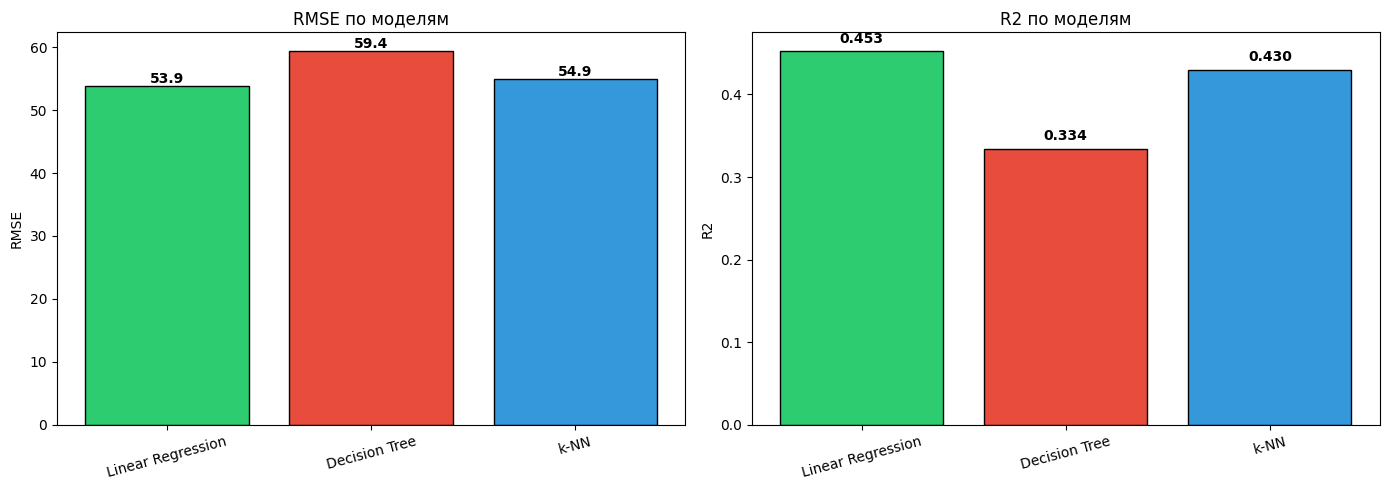

In [ ]:
# TODO: постройте минимум одну визуализацию:
# - confusion matrix, или
# - важность признаков (feature_importances_), или
# - график сравнения метрик по моделям, или
# - дерево решений (plot_tree), или
# - learning curve

# сравнение RMSE и R2 по моделям
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#e74c3c', '#3498db']

# RMSE (меньше = лучше)
bars1 = axes[0].bar(results['model'], results['RMSE'], color=colors, edgecolor='black')
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE по моделям')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars1, results['RMSE']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}', ha='center', fontweight='bold')

# R2 (больше = лучше)
bars2 = axes[1].bar(results['model'], results['R2'], color=colors, edgecolor='black')
axes[1].set_ylabel('R2')
axes[1].set_title('R2 по моделям')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, results['R2']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


**Вопрос для отчёта:** почему вы выбрали именно эти метрики? В каких случаях accuracy может вводить в заблуждение (например, при дисбалансе классов)?

_Ваш ответ:_

Я выбрал MSE, RMSE и R2, потому что задача регрессионная. MSE - это средний квадрат ошибки. RMSE - корень из MSE, поэтому измеряется в тех же единицах, что target: RMSE = 53.85 означает, что модель в среднем ошибается на +-54 единицы шкалы прогрессирования диабета (диапазон 25–346), и это меньше стандартного отклонения target (77.1), значит модель предсказывает лучше, чем простое угадывание среднего. Коэффициент детерминации R2 показывает долю объясненной дисперсии: 0.453 означает, что модель объясняет 45% разброса target (умеренная объяснительная способность), а остальные 55% приходятся на факторы, не учтенные в признаках.

## 6. Анализ ошибок

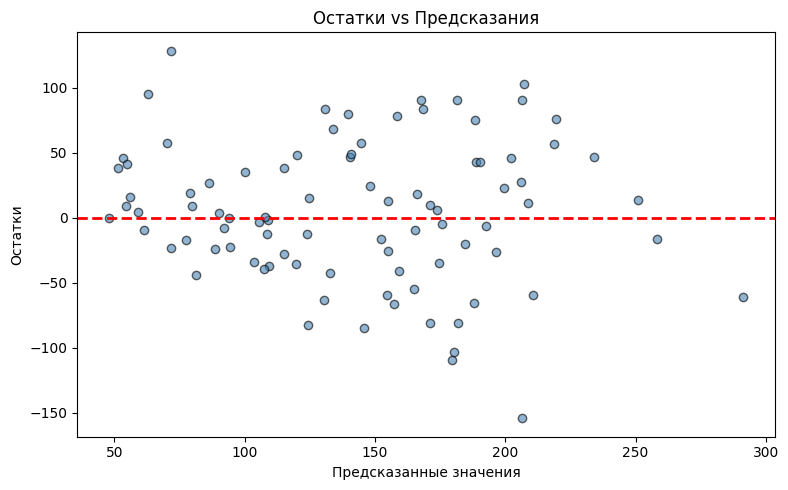

Топ-5 наибольших ошибок:
     real    pred   error
61   52.0  206.49 -154.49
46  200.0   71.67  128.33
1    70.0  179.52 -109.52
27   77.0  180.39 -103.39
20  310.0  207.35  102.65

Средняя ошибка: 3.91
Медиана ошибки: 3.78
Корреляция остатков с предсказаниями: -0.0874


In [ ]:
# TODO: проанализируйте ошибки лучшей модели
# - какие объекты классифицируются неверно?
# - есть ли систематическая ошибка (например, путаница конкретных двух классов)?

# анализ ошибок лучшей модели
y_pred_best = model_1.predict(X_test)
residuals = y_test - y_pred_best

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_pred_best, residuals, alpha=0.6, color='steelblue', edgecolor='black')
ax.axhline(y=0, color='red', linestyle='--', lw=2)
ax.set_xlabel('Предсказанные значения')
ax.set_ylabel('Остатки')
ax.set_title('Остатки vs Предсказания')
plt.tight_layout()
plt.show()

# топ-5 ошибок
errors_df = pd.DataFrame({
    'real': y_test.values,
    'pred': y_pred_best,
    'error': residuals.values
}).sort_values('error', key=abs, ascending=False)

print("Топ-5 наибольших ошибок:")
print(errors_df.head().round(2))

# систематическая ошибка
print(f"\nСредняя ошибка: {residuals.mean():.2f}")
print(f"Медиана ошибки: {residuals.median():.2f}")
print(f"Корреляция остатков с предсказаниями: {np.corrcoef(y_pred_best, residuals)[0,1]:.4f}")


Топ-5 ошибок показывает, что модель плохо предсказывает экстремальные значения target: низкие завышает (52 - 206), высокие занижает (310 - 207). Это проблема линейной регрессии она сглаживает края к среднему. Систематической ошибки нет: bias = 3.91 = 0 (то есть по сравнению со средним target = 152, это очень мало), медиана = 3.78, корреляция остатков с предсказаниями = -0.087 = 0, то связи между величиной предсказания и ошибкой практически нет. Модель несмещённая, ошибки распределены симметрично.

## 7. Сравнение моделей и вывод

**Вопрос для отчёта:** какая модель показала лучший результат по выбранным метрикам? Согласуется ли это с ожиданиями, учитывая структуру данных (линейность, размер выборки, число признаков)? Какую модель вы бы выбрали в качестве baseline и почему?

_Ваш ответ:_

Лучший результат показала линейная регрессия (RMSE = 53.85, R2 = 0.453). Дерево решений — худшее (R2 = 0.334), k-NN — посередине (R2 = 0.430). Это согласуется с ожиданиями: признаки имеют линейные корреляции с target
(bmi: 0.59, s5: 0.57), выборка малая (353 объекта в train), признаков немного (10).
Линейная модель с 11 параметрами устойчива на таких данных, тогда как дерево
и k-NN переобучаются.
В качестве baseline выбрал бы линейную регрессию: простая, интерпретируемая,
без гиперпараметров, показывает хорошее качество.

---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже

### С1. Кластеризация как альтернативный взгляд на данные
Примените unsupervised-подход (например, KMeans) к тем же признакам без использования целевой переменной. Сравните полученные кластеры с реальными классами/значениями целевой переменной. Обсудите: совпадает ли структура кластеров с реальной разметкой? Что это говорит о структуре данных?

### С2. Классический baseline vs простой MLP
Обучите простую нейросеть (MLPClassifier/MLPRegressor из sklearn, либо небольшую сеть на PyTorch) на тех же признаках и сравните её с лучшей классической моделью по тем же метрикам. Объясните, почему нейросеть выигрывает/проигрывает при данном объёме данных и числе признаков.

### С3. Устойчивость вывода о «лучшей» модели к выбору метрики
Постройте искусственный дисбаланс классов (например, undersampling одного класса) и пересчитайте метрики для всех моделей. Проверьте: меняется ли ранжирование моделей при использовании accuracy против F1/recall? Сделайте вывод о том, почему выбор метрики критичен при дисбалансе.

### С4. Кросс-валидация и доверительный интервал качества
Замените единичный train/test split на k-fold кросс-валидацию (cross_val_score) для всех моделей. Постройте boxplot распределения метрики по фолдам. Обсудите, насколько стабильны результаты моделей.



Результаты на тестовой выборке:
            model         MSE      RMSE       R2
Linear Regression 2900.193628 53.853446 0.452603
              MLP 2992.293797 54.701863 0.435219


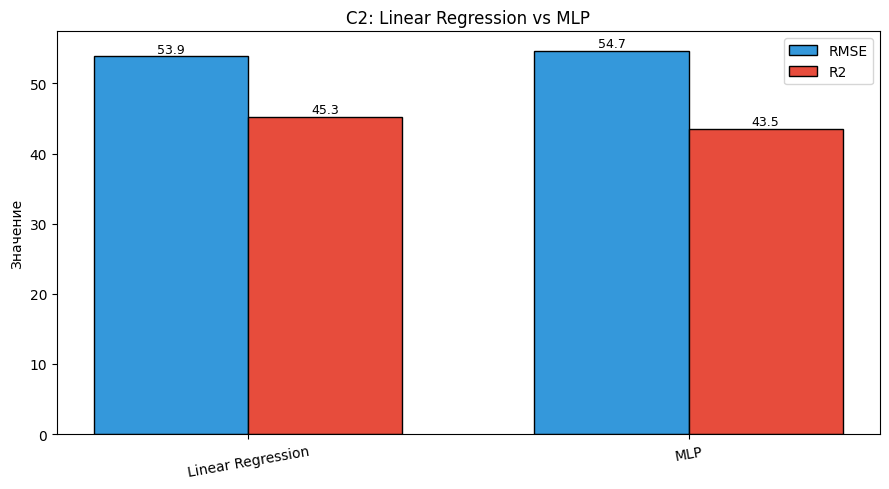

In [ ]:
# TODO: реализуйте выбранные задания (С1-С4) здесь

# С2
from sklearn.neural_network import MLPRegressor
# Baseline: линейная регрессия
y_pred_lr = model_1.predict(X_test)

# MLP
model_mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=2000,
    random_state=RANDOM_STATE,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20
)
model_mlp.fit(X_train, y_train)
y_pred_mlp = model_mlp.predict(X_test)

# сравнение
comparison = pd.DataFrame([
    evaluate_model(model_1, X_test, y_test, 'Linear Regression'),
    evaluate_model(model_mlp, X_test, y_test, 'MLP'),
])
print("\nРезультаты на тестовой выборке:")
print(comparison.to_string(index=False))

# визуализация
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(comparison))
width = 0.35

bars1 = ax.bar(x - width/2, comparison['RMSE'], width,
               label='RMSE', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, comparison['R2'] * 100, width,
               label='R2', color='#e74c3c', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(comparison['model'], rotation=10)
ax.set_ylabel('Значение')
ax.set_title('С2: Linear Regression vs MLP')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

Нейросеть MLP показала RMSE = 54.70 и R2 = 0.435, немного уступив линейной регрессии (RMSE = 53.85, R2 = 0.453). Это объясняется тремя причинами: малой выборкой (353 объекта - MLP с тысячами параметров переобучается, тогда как линейная регрессия с 11 параметрами устойчива), малым числом признаков (10 - нейросети раскрываются при десятках-сотнях признаков и сложных взаимодействиях) и линейной природой зависимостей (корреляции bmi 0.59 и s5 0.57 с target линейны, поэтому усложнение модели не даёт выигрыша). На малых табличных данных с линейными зависимостями классическая модель выигрывает у нейросетей, а MLP эффективна при больших данных и нелинейных зависимостях.


Linear Regression:
  R2 по фолдам: [0.4701 0.5368 0.4111 0.4913 0.4925]
  Среднее: 0.4804 +- 0.0409

Decision Tree:
  R2 по фолдам: [ 0.33    0.2287 -0.0192  0.3157  0.1655]
  Среднее: 0.2041 +- 0.1267

k-NN:
  R2 по фолдам: [0.3004 0.3311 0.2013 0.3856 0.4574]
  Среднее: 0.3352 +- 0.0856

MLP:
  R2 по фолдам: [0.4524 0.3721 0.3602 0.4649 0.482 ]
  Среднее: 0.4263 +- 0.0501


/tmp/ipykernel_659/1983093049.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True)


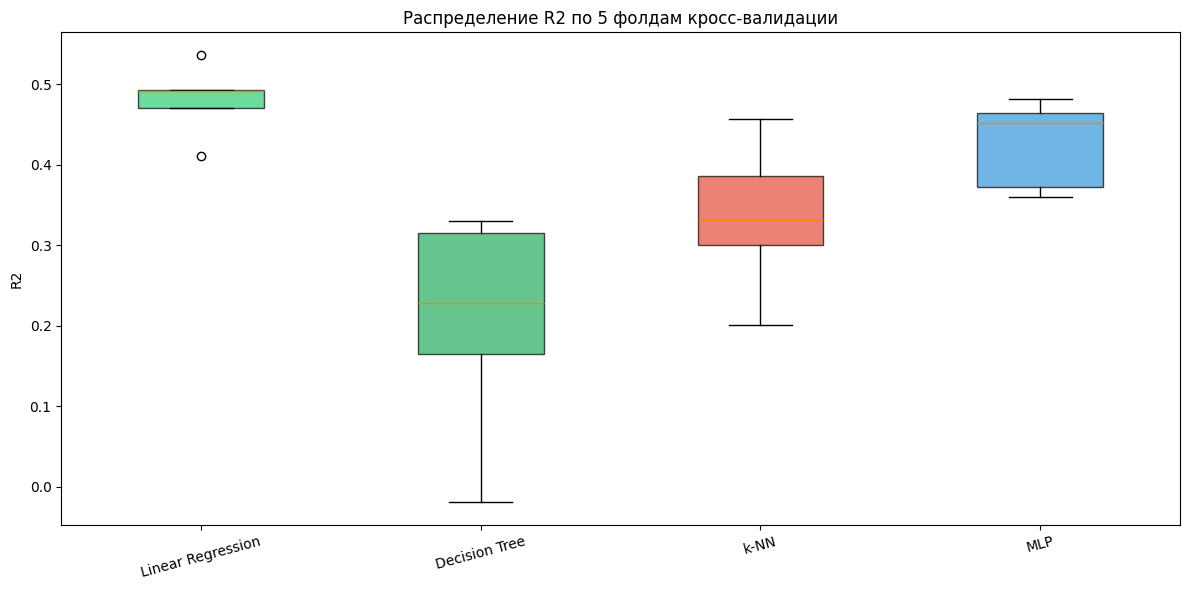

In [ ]:
# С4
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# словарь моделей
models_cv = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE),
    'k-NN': KNeighborsRegressor(n_neighbors=5),
    'MLP': MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=2000, random_state=RANDOM_STATE, early_stopping=True),
}

# кросс-валидация по R2
cv_results = {}
for name, model in models_cv.items():
    scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='r2')
    cv_results[name] = scores
    print(f"\n{name}:")
    print(f"  R2 по фолдам: {scores.round(4)}")
    print(f"  Среднее: {scores.mean():.4f} +- {scores.std():.4f}")

# Boxplot распределения R2 по фолдам
fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True)

colors_box = ['#2ecc71', '#27ae60', '#e74c3c', '#3498db', '#9b59b6']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('R2')
ax.set_title('Распределение R2 по 5 фолдам кросс-валидации')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

Кросс-валидация показала, что линейная регрессия самая стабильная
(R2 = 0.480 +- 0.041), за ней MLP (0.426 +- 0.050), k-NN (0.335 +- 0.086)
и дерево решений (0.204 +- 0.127). Дерево дало отрицательный R2 на одном
фолде, что является типичным признаком переобучения. Поэтому линейная регрессия -
не только лучшая по метрикам, но и самая надёжная.

---



## Требования к сдаче
- Ноутбук выполняется целиком без ошибок (Kernel → Restart & Run All).
- Все `# TODO` заполнены, все вопросы для отчёта содержат письменный ответ.
- Минимум 3 модели, минимум 2 метрики, минимум 1 визуализация.
